In [1]:
import pandas as pd
import numpy as np
from scipy import stats                                                                             

In [2]:
uninsured = pd.read_csv("data/sahie_clean/sahie_all_years.csv")
uninsured = uninsured.groupby(["year", "County"]).mean()
uninsured

county_fips     population  num_uninsured    num_insured  \
year County                                                                
2008 Alameda            1.0  252393.180000   50571.160000  201821.780000   
     Alpine             3.0     217.020000      58.560000     158.380000   
     Amador             5.0    5683.680000    1337.700000    4345.940000   
     Butte              7.0   46887.740000   10414.340000   36473.360000   
     Calaveras          9.0    8454.160000    1965.280000    6489.020000   
...                     ...            ...            ...            ...   
2022 Tulare           107.0   86739.406250   10274.802083   76464.604167   
     Tuolumne         109.0    6941.760417     528.854167    6412.906250   
     Ventura          111.0  112163.281250   14562.177083   97601.104167   
     Yolo             113.0   31108.500000    2534.500000   28574.000000   
     Yuba             115.0   14308.250000    1213.916667   13094.333333   

                pct_uninsured  pct_uninsured_moe  
year County                                       
2008 Alameda        24.526000           2.148000  
     Alpine         31.166000           4.810000  
     Amador         27.908000           4.004000  
     Butte          22.938000           2.954000  
     Calaveras      26.604000           3.992000  
...                       ...                ...  
2022 Tulare         12.470833           2.128125  
     Tuolumne        8.258333           2.335417  
     Ventura        14.978125           2.330208  
     Yolo            9.168750           2.241667  
     Yuba            8.876042           2.370833  

[870 rows x 6 columns]

In [3]:
crime = pd.read_csv("../county_crime_combined.csv")
crime = crime[["year", "county", 'Violent Crimes']][crime['year'] != 2023]
crime = crime.drop_duplicates()
crime['Violent Crimes'] = crime['Violent Crimes'].str.replace(',', '').astype(float).astype('Int64')
crime

,year,county,Violent Crimes
0,2008,San Joaquin,6156
1,2009,San Joaquin,5531
2,2010,San Joaquin,5524
3,2011,San Joaquin,5694
4,2012,San Joaquin,6249
...,...,...,...
980,2018,Lake,338
981,2019,Lake,347
982,2020,Lake,351
983,2021,Lake,392


In [4]:
merged = uninsured.reset_index().merge(                                                                  
      crime[["year", "county", "Violent Crimes"]],                                                         
      left_on=["year", "County"],                                                                          
      right_on=["year", "county"],
      how="left"
  ).drop(columns="county")
merged

,year,County,county_fips,population,num_uninsured,num_insured,pct_uninsured,pct_uninsured_moe,Violent Crimes
0,2008,Alameda,1.0,252393.180000,50571.160000,201821.780000,24.526000,2.148000,12778
1,2008,Alpine,3.0,217.020000,58.560000,158.380000,31.166000,4.810000,14
2,2008,Amador,5.0,5683.680000,1337.700000,4345.940000,27.908000,4.004000,127
3,2008,Butte,7.0,46887.740000,10414.340000,36473.360000,22.938000,2.954000,836
4,2008,Calaveras,9.0,8454.160000,1965.280000,6489.020000,26.604000,3.992000,93
...,...,...,...,...,...,...,...,...,...
865,2022,Tulare,107.0,86739.406250,10274.802083,76464.604167,12.470833,2.128125,2087
866,2022,Tuolumne,109.0,6941.760417,528.854167,6412.906250,8.258333,2.335417,375
867,2022,Ventura,111.0,112163.281250,14562.177083,97601.104167,14.978125,2.330208,1645
868,2022,Yolo,113.0,31108.500000,2534.500000,28574.000000,9.168750,2.241667,596


# uninsured vs violent crimes visualization

In [5]:
merged["violent_crimes_per_capita"] = merged["Violent Crimes"] / merged["population"]                    
                
clean = merged.dropna(subset=["pct_uninsured", "violent_crimes_per_capita"])
x = clean["pct_uninsured"]
y = clean["violent_crimes_per_capita"]

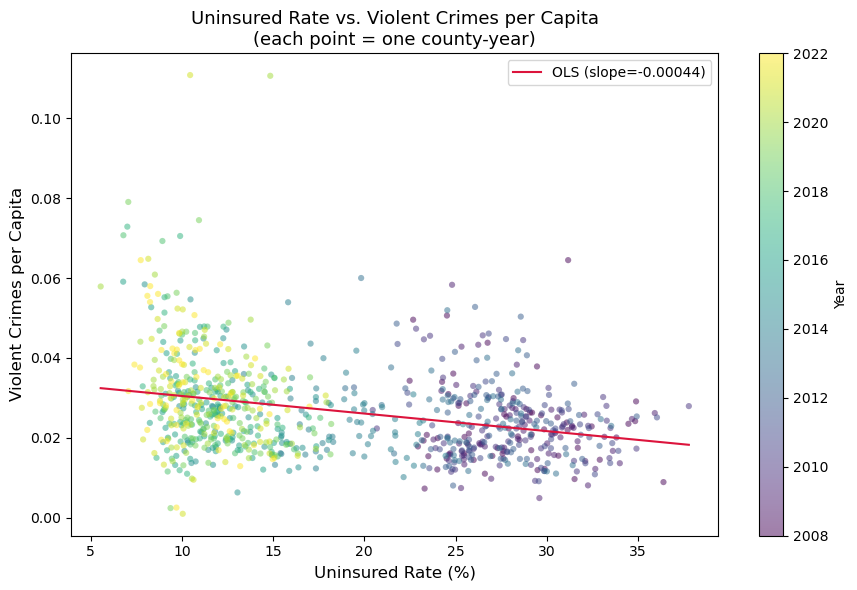

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(9, 6))

years = clean["year"]
norm = plt.Normalize(years.min(), years.max())
colors = cm.viridis(norm(years))

sc = ax.scatter(x, y, c=years, cmap="viridis", alpha=0.5, s=20, linewidths=0)

# OLS trend line
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, m * xline + b, color="crimson", linewidth=1.5, label=f"OLS (slope={m:.5f})")

plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("Uninsured Rate (%)", fontsize=12)
ax.set_ylabel("Violent Crimes per Capita", fontsize=12)
ax.set_title("Uninsured Rate vs. Violent Crimes per Capita\n(each point = one county-year)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


as seen in the other notebook, the distribution of uninsured rates seems to be bimodal. This difference was most likely caused by some action taken in 2013 as seen in the eda.

The relationship between uninsured rate and violent crimes per capita seems relatively linear. Though, we saw below that this relationship is statistically significant but the correlation is weak.

## stats test

In [7]:
# Pearson
r, p = stats.pearsonr(x, y)
print(f"Pearson r: {r:.4f}, p-value: {p:.4f}")

# Spearman
rho, p_s = stats.spearmanr(x, y)
print(f"Spearman rho: {rho:.4f}, p-value: {p_s:.4f}")

Pearson r: -0.3070, p-value: 0.0000
Spearman rho: -0.3344, p-value: 0.0000


- Direction (negative): Counties with higher uninsured rates tend to have lower violent crimes per       
capita, and vice versa. This is counterintuitive but likely reflects a confound — wealthier, denser urban
  counties (e.g. SF, LA) have low uninsured rates but high violent crime per capita.                      
- Strength (r ≈ -0.31, rho ≈ -0.33): Weak. Uninsured rate explains only about 9% of the variance in      
violent crimes per capita (r² = 0.09). Most of the variation is driven by other factors.
- P-value (≈ 0.000): The result is statistically significant — not due to random chance. But with 870
observations, even weak effects become significant, so don't over-interpret this.
- Pearson vs Spearman agreement: Both give similar results, which means the relationship is consistent
whether you assume linearity (Pearson) or not (Spearman). No major outlier distortion.

Bottom line: There is a statistically significant but weak negative relationship. You cannot conclude
that uninsured rates drive violent crime — the correlation is likely explained by confounding variables
like urbanization or income.

# Rolling Window

In [8]:
results = []                                                                                             
for lag in range(-5, 6):                                                                               
    lagged = merged.copy()                                                                               
    lagged["year"] = lagged["year"] + lag                                                                
    temp = lagged.merge(                                                                                 
        merged[["year", "County", "violent_crimes_per_capita"]],                                         
        on=["year", "County"],
        suffixes=("_uninsured", "_crime")
    ).dropna()

    pearson_r, pearson_p = stats.pearsonr(temp["pct_uninsured"], temp["violent_crimes_per_capita_crime"])
    spearman_r, spearman_p = stats.spearmanr(temp["pct_uninsured"],
temp["violent_crimes_per_capita_crime"])

    results.append({
        "lag": lag,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_r,
        "spearman_p": spearman_p,
        "n": len(temp)
    })

lag_df = pd.DataFrame(results)
print(lag_df)

    lag  pearson_r     pearson_p  spearman_rho    spearman_p    n
0    -5  -0.199832  1.227051e-06     -0.227954  2.836258e-08  580
1    -4  -0.221042  1.678756e-08     -0.246757  2.641395e-10  638
2    -3  -0.233607  4.419960e-10     -0.257955  4.833845e-12  696
3    -2  -0.257241  7.340368e-13     -0.275277  1.409740e-14  754
4    -1  -0.271912  3.135348e-15     -0.289006  4.364732e-17  812
5     0  -0.307038  1.895045e-20     -0.334400  3.573745e-24  870
6     1  -0.312935  6.606739e-20     -0.324065  2.613686e-21  812
7     2  -0.312858  1.388307e-18     -0.316507  5.265609e-19  754
8     3  -0.306294  1.390496e-16     -0.306526  1.315866e-16  696
9     4  -0.282498  3.591609e-13     -0.289506  8.751810e-14  638
10    5  -0.281791  4.767266e-12     -0.299066  1.895879e-13  580


1. Consistently negative and significant across all lags                                                 
Every single lag — in both directions — is statistically significant (p ≈ 0). The negative relationship
between uninsured rate and violent crimes per capita holds no matter how you shift the variables.        
                
2. The peak correlation is at lags 1–2 (uninsured leads crime)

| Lag | Pearson r | Pearson p | Spearman rho | Spearman p | n |
|-----|-----------|-----------|--------------|------------|---|
| -5 | -0.200 | 1.23e-06 | -0.228 | 2.84e-08 | 580 |
| -4 | -0.221 | 1.68e-08 | -0.247 | 2.64e-10 | 638 |
| -3 | -0.234 | 4.42e-10 | -0.258 | 4.83e-12 | 696 |
| -2 | -0.257 | 7.34e-13 | -0.275 | 1.41e-14 | 754 |
| -1 | -0.272 | 3.14e-15 | -0.289 | 4.36e-17 | 812 |
|  0 | -0.307 | 1.90e-20 | -0.334 (peak)| 3.57e-24 | 870 |
|  1 | -0.313 (peak) | 6.61e-20 | -0.324 | 2.61e-21 | 812 |
|  2 | -0.313 (peak) | 1.39e-18 | -0.317 | 5.27e-19 | 754 |
|  3 | -0.306 | 1.39e-16 | -0.307 | 1.32e-16 | 696 |
|  4 | -0.282 | 3.59e-13 | -0.290 | 8.75e-14 | 638 |
|  5 | -0.282 | 4.77e-12 | -0.299 | 1.90e-13 | 580 |

uninsured rates in year X are slightly more correlated with crime in year X+1 or X+2 than in the same year. However, the improvement is tiny (~0.006).

3. Negative lags weaken steadily
As crime leads further ahead of uninsured (lags -3 to -5), correlation drops to ~-0.20. This suggests
crime is not a strong predictor of future uninsured rates.

4. Overall conclusion
there is a slight lagged effect — but it doesn't meaningfully change the story. The correlation is weak at every lag (r never exceeds -0.32). Lagging doesn't reveal a hidden
strong relationship; it just confirms a consistently weak one. The confounding variables (urbanization,
income) likely still dominate.

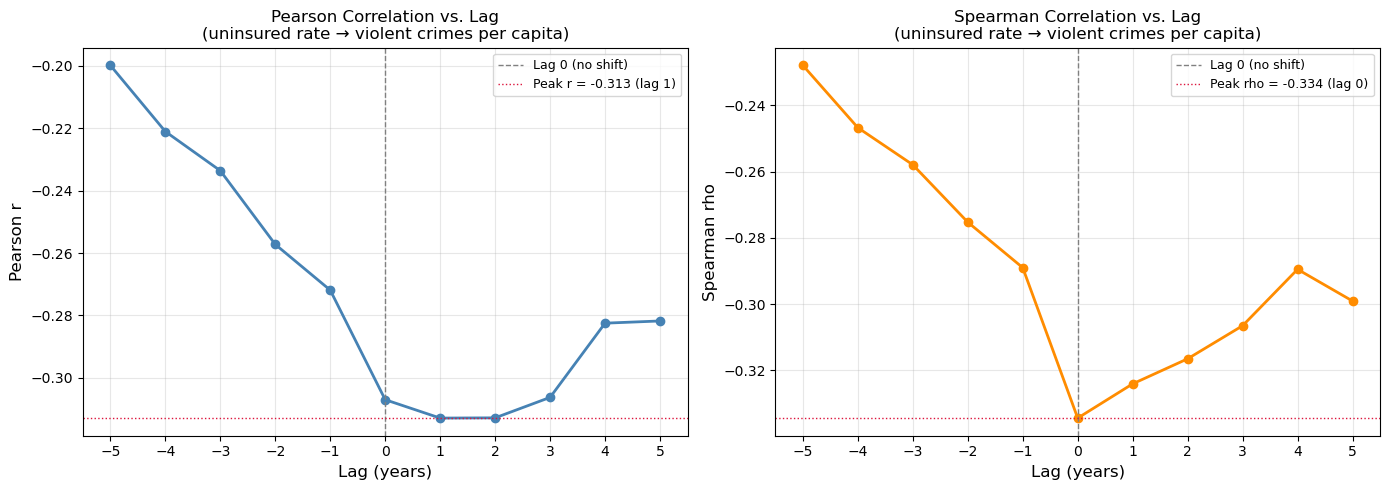

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Pearson ---
ax1.plot(lag_df["lag"], lag_df["pearson_r"], marker="o", color="steelblue", linewidth=2, markersize=6)
ax1.axvline(0, color="gray", linestyle="--", linewidth=1, label="Lag 0 (no shift)")
ax1.axhline(lag_df["pearson_r"].min(), color="crimson", linestyle=":", linewidth=1,
            label=f'Peak r = {lag_df["pearson_r"].min():.3f} (lag {lag_df.loc[lag_df["pearson_r"].idxmin(), "lag"]})')
ax1.set_xlabel("Lag (years)", fontsize=12)
ax1.set_ylabel("Pearson r", fontsize=12)
ax1.set_title("Pearson Correlation vs. Lag\n(uninsured rate → violent crimes per capita)", fontsize=12)
ax1.set_xticks(lag_df["lag"])
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Spearman ---
ax2.plot(lag_df["lag"], lag_df["spearman_rho"], marker="o", color="darkorange", linewidth=2, markersize=6)
ax2.axvline(0, color="gray", linestyle="--", linewidth=1, label="Lag 0 (no shift)")
ax2.axhline(lag_df["spearman_rho"].min(), color="crimson", linestyle=":", linewidth=1,
            label=f'Peak rho = {lag_df["spearman_rho"].min():.3f} (lag {lag_df.loc[lag_df["spearman_rho"].idxmin(), "lag"]})')
ax2.set_xlabel("Lag (years)", fontsize=12)
ax2.set_ylabel("Spearman rho", fontsize=12)
ax2.set_title("Spearman Correlation vs. Lag\n(uninsured rate → violent crimes per capita)", fontsize=12)
ax2.set_xticks(lag_df["lag"])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ADF test - see youtube videos for explanation

In [10]:
crime_by_year

NameError: name 'crime_by_year' is not defined

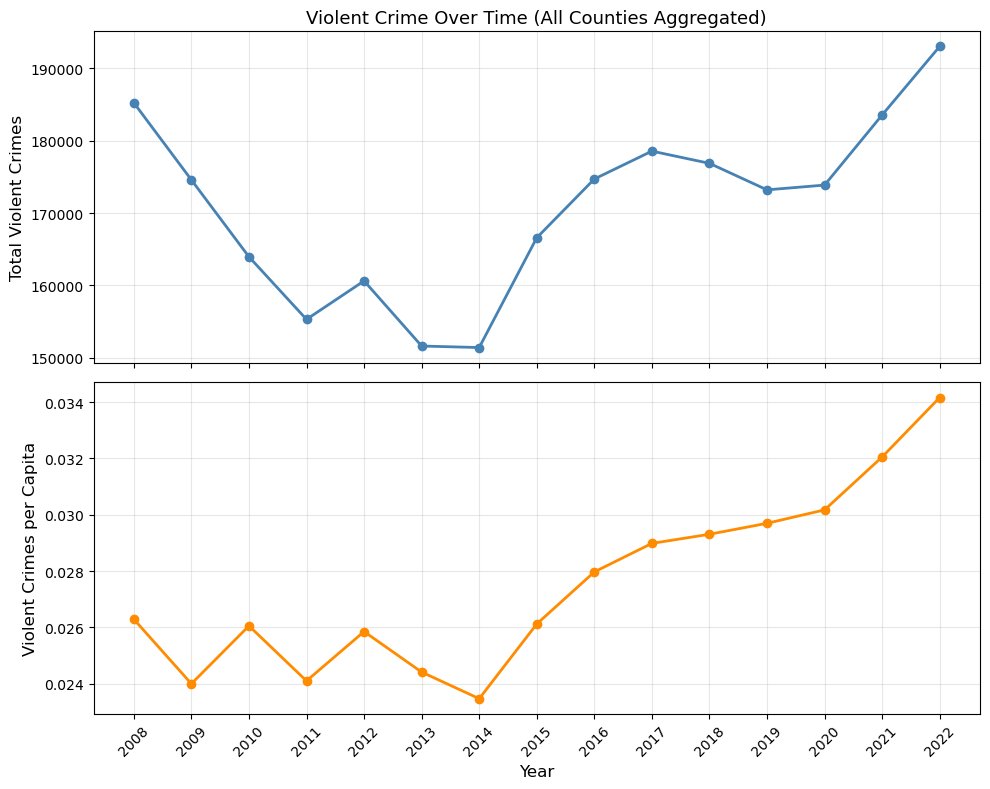

In [ ]:
crime_by_year = merged.groupby("year")[["Violent Crimes", "population"]].sum()
crime_by_year["violent_crimes_per_capita"] = crime_by_year["Violent Crimes"] / crime_by_year["population"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(crime_by_year.index, crime_by_year["Violent Crimes"], marker="o", color="steelblue", linewidth=2)
ax1.set_ylabel("Total Violent Crimes", fontsize=12)
ax1.set_title("Violent Crime Over Time (All Counties Aggregated)", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(crime_by_year.index, crime_by_year["violent_crimes_per_capita"], marker="o", color="darkorange", linewidth=2)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_ylabel("Violent Crimes per Capita", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.xticks(crime_by_year.index, rotation=45)
plt.tight_layout()
plt.show()


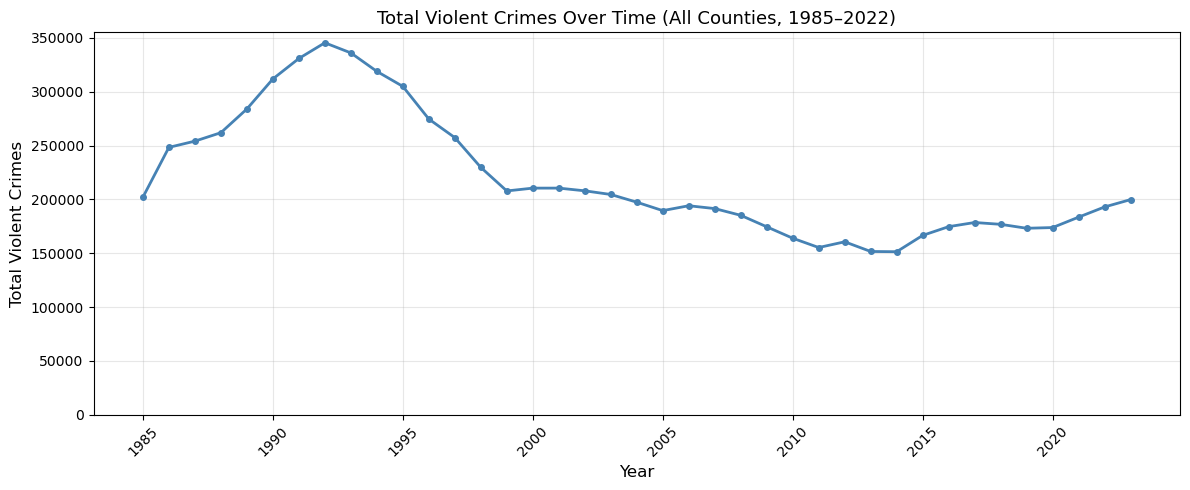

In [ ]:
crime_full = pd.read_csv("../county_crime_combined_all_years.csv")                                       
crime_full = crime_full[["year", "county", "Violent Crimes"]]               
crime_full = crime_full.drop_duplicates()                                                                
crime_full["Violent Crimes"] = crime_full["Violent Crimes"].str.replace(",",                             
"").astype(float).astype("Int64")                                                                        
                                                                                                        
crime_by_year_full = crime_full.groupby("year")["Violent Crimes"].sum().reset_index()                    
                                                                                                        
fig, ax = plt.subplots(figsize=(12, 5))                                                                  
ax.plot(crime_by_year_full["year"], crime_by_year_full["Violent Crimes"],
        marker="o", color="steelblue", linewidth=2, markersize=4)                                        
ax.set_xlabel("Year", fontsize=12)                                                                       
ax.set_ylabel("Total Violent Crimes", fontsize=12)
ax.set_title("Total Violent Crimes Over Time (All Counties, 1985–2022)", fontsize=13)                    
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)                                                                                 
plt.xticks(rotation=45)
plt.tight_layout()                                                                                       
plt.show()

change y axis to start from 0 to prevent exageration

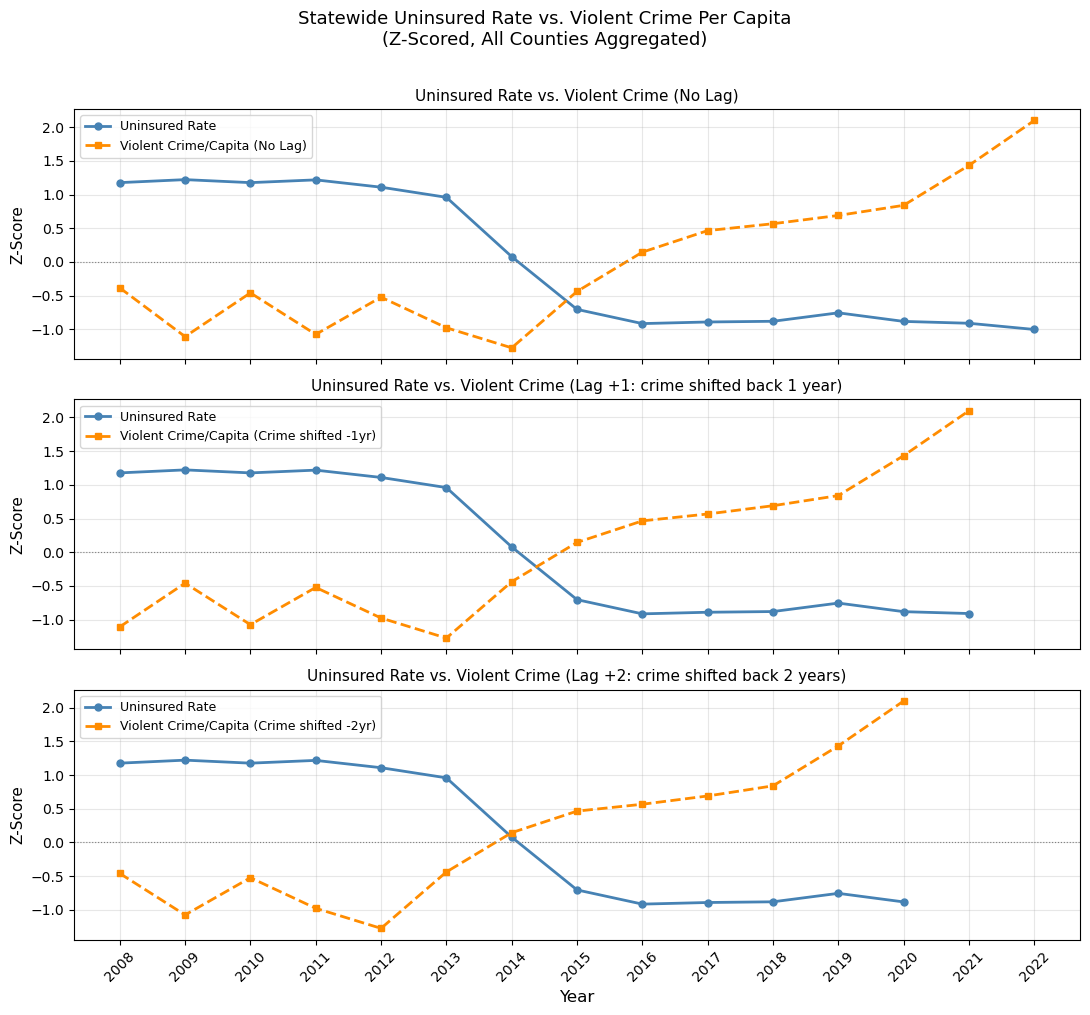

In [ ]:
state = merged.groupby("year")[["pct_uninsured", "Violent Crimes", "population"]].sum()
state["violent_crimes_per_capita"] = state["Violent Crimes"] / state["population"]

# z-score both series
def zscore(s):
    return (s - s.mean()) / s.std()

state["z_uninsured"] = zscore(state["pct_uninsured"])
state["z_crime"] = zscore(state["violent_crimes_per_capita"])
state["z_crime_lag1"] = state["z_crime"].shift(-1)  # crime shifted back 1 yr (uninsured leads)
state["z_crime_lag2"] = state["z_crime"].shift(-2)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

configs = [
    ("z_crime",      "No Lag",          "Uninsured Rate vs. Violent Crime (No Lag)"),
    ("z_crime_lag1", "Crime shifted -1yr", "Uninsured Rate vs. Violent Crime (Lag +1: crime shifted back 1 year)"),
    ("z_crime_lag2", "Crime shifted -2yr", "Uninsured Rate vs. Violent Crime (Lag +2: crime shifted back 2 years)"),
]

for ax, (crime_col, crime_label, title) in zip(axes, configs):
    plot_data = state[["z_uninsured", crime_col]].dropna()
    ax.plot(plot_data.index, plot_data["z_uninsured"], color="steelblue", marker="o",
            linewidth=2, markersize=5, label="Uninsured Rate")
    ax.plot(plot_data.index, plot_data[crime_col], color="darkorange", marker="s",
            linewidth=2, markersize=5, linestyle="--", label=f"Violent Crime/Capita ({crime_label})")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_ylabel("Z-Score", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Year", fontsize=12)
plt.xticks(state.index, rotation=45)
plt.suptitle("Statewide Uninsured Rate vs. Violent Crime Per Capita\n(Z-Scored, All Counties Aggregated)", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


check out autocorrelation functions

trying to show that with a lag of -1 or -2, uninsured rates have a stronger inverse correlation to violent crimes

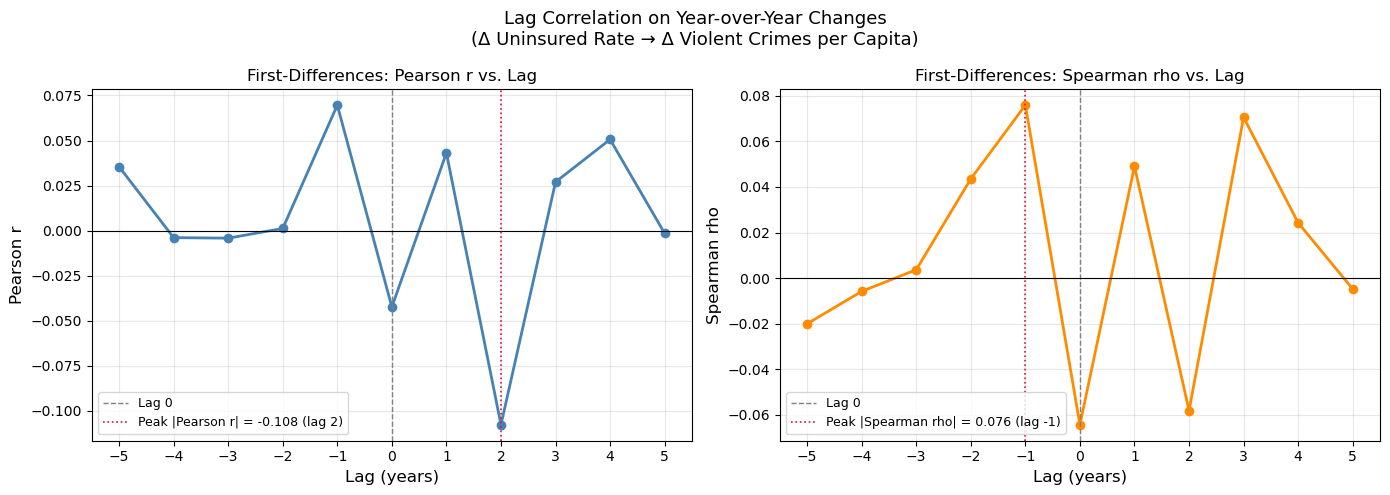

 lag  pearson_r  pearson_p  spearman_rho  spearman_p   n
  -5   0.035486   0.418472     -0.020019    0.648156 522
  -4  -0.003886   0.925589     -0.005808    0.889003 580
  -3  -0.004173   0.916221      0.003703    0.925632 638
  -2   0.001198   0.974829      0.043561    0.251092 696
  -1   0.069637   0.055962      0.075916    0.037149 754
   0  -0.042333   0.228208     -0.064316    0.066982 812
   1   0.043109   0.237082      0.049076    0.178254 754
   2  -0.107693   0.004451     -0.058115    0.125594 696
   3   0.026979   0.496359      0.070568    0.074881 638
   4   0.050597   0.223719      0.024281    0.559501 580
   5  -0.001519   0.972379     -0.004750    0.913788 522


In [11]:
# First differences within each county
fd = merged.sort_values(["County", "year"]).copy()
fd["d_uninsured"] = fd.groupby("County")["pct_uninsured"].diff()
fd["d_crime_pc"] = fd.groupby("County")["violent_crimes_per_capita"].diff()
fd = fd.dropna(subset=["d_uninsured", "d_crime_pc"])

# Lag correlation on first differences
fd_results = []
for lag in range(-5, 6):
    lagged = fd.copy()
    lagged["year"] = lagged["year"] + lag
    temp = lagged.merge(
        fd[["year", "County", "d_crime_pc"]],
        on=["year", "County"],
        suffixes=("_uninsured", "_crime")
    ).dropna()

    pearson_r, pearson_p = stats.pearsonr(temp["d_uninsured"], temp["d_crime_pc_crime"])
    spearman_r, spearman_p = stats.spearmanr(temp["d_uninsured"], temp["d_crime_pc_crime"])
    fd_results.append({
        "lag": lag,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_r,
        "spearman_p": spearman_p,
        "n": len(temp)
    })

fd_lag_df = pd.DataFrame(fd_results)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in [
    (ax1, "pearson_r",    "Pearson r",    "steelblue"),
    (ax2, "spearman_rho", "Spearman rho", "darkorange"),
]:
    ax.plot(fd_lag_df["lag"], fd_lag_df[col], marker="o", color=color, linewidth=2, markersize=6)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="Lag 0")
    ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
    peak_idx = fd_lag_df[col].abs().idxmax()
    peak_lag = fd_lag_df.loc[peak_idx, "lag"]
    peak_val = fd_lag_df.loc[peak_idx, col]
    ax.axvline(peak_lag, color="crimson", linestyle=":", linewidth=1.2,
               label=f"Peak |{label}| = {peak_val:.3f} (lag {peak_lag})")
    ax.set_xlabel("Lag (years)", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f"First-Differences: {label} vs. Lag", fontsize=12)
    ax.set_xticks(fd_lag_df["lag"])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Lag Correlation on Year-over-Year Changes\n(Δ Uninsured Rate → Δ Violent Crimes per Capita)", 
             fontsize=13)
plt.tight_layout()
plt.show()

print(fd_lag_df.to_string(index=False))


## next time

plot violent crimes against lag

check out notebook from conan

show crime rate as it moves over time

# Dickey Fuller Tests

Test: population data, uninsured data, violent crime data (monthly and yearly)

visualize uninsured data

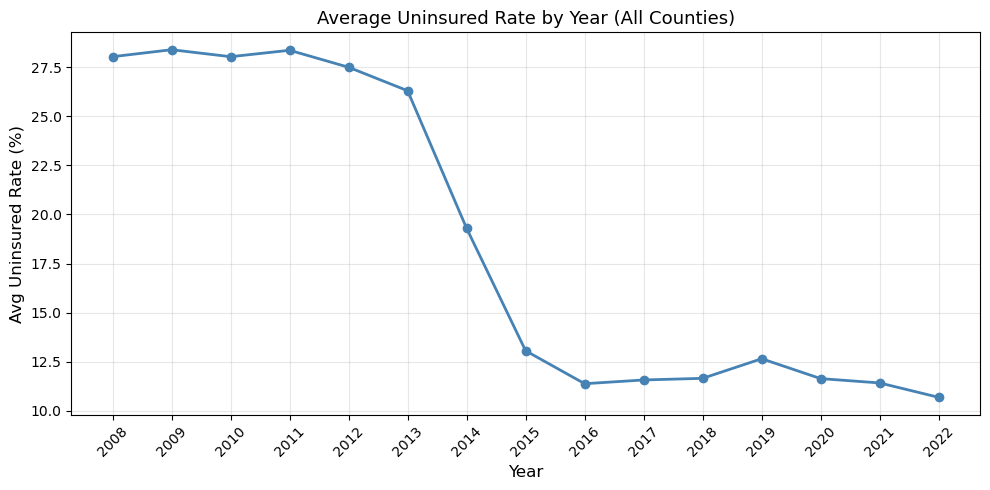

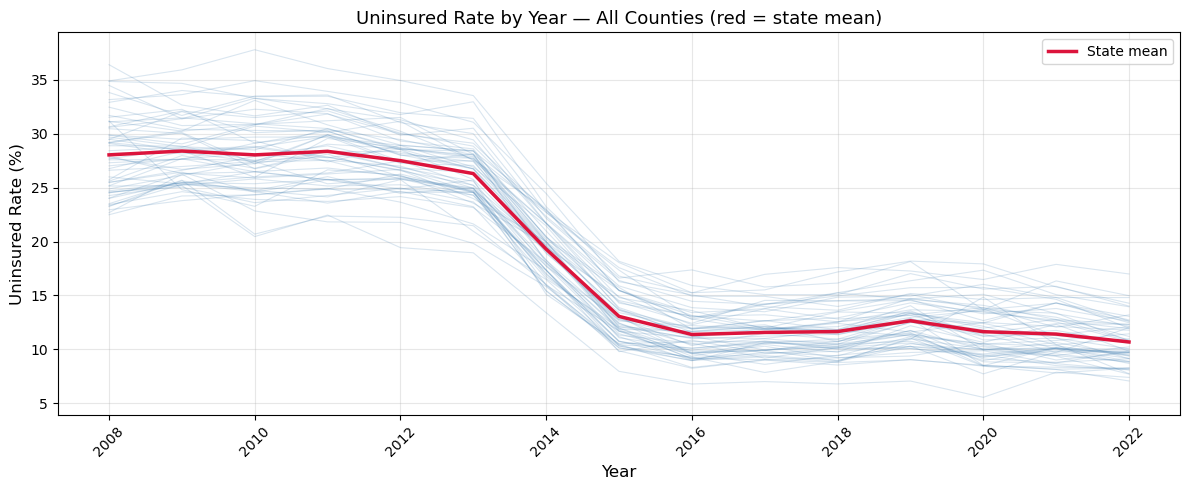

In [16]:
uninsured_by_year = uninsured.reset_index().groupby("year")["pct_uninsured"].mean()                      
                                                                                                        
fig, ax = plt.subplots(figsize=(10, 5))                                                                  
ax.plot(uninsured_by_year.index, uninsured_by_year.values, marker="o", color="steelblue", linewidth=2)   
ax.set_xlabel("Year", fontsize=12)                                                                       
ax.set_ylabel("Avg Uninsured Rate (%)", fontsize=12)                                                     
ax.set_title("Average Uninsured Rate by Year (All Counties)", fontsize=13)                               
ax.set_xticks(uninsured_by_year.index)                                                                   
plt.xticks(rotation=45)                                                                                
ax.grid(True, alpha=0.3)                                                                                 
plt.tight_layout()                                                                                       
plt.show()
                                                                                                        
# This plots the mean uninsured rate across all counties for each year. If you'd rather see total counts   
# instead, swap out the aggregation:
                                                                                                        
# Total uninsured count by year                                                                        
uninsured_by_year = uninsured.reset_index().groupby("year")["num_uninsured"].sum()
                                                                                                        
# Or if you want to see the distribution across counties per year (more detail):                           
                                                                                                        
fig, ax = plt.subplots(figsize=(12, 5))                                                                  
for county, group in uninsured.reset_index().groupby("County"):                                          
    ax.plot(group["year"], group["pct_uninsured"], alpha=0.2, color="steelblue", linewidth=0.8)
                                                                                                        
# Overlay the statewide mean                                                                           
mean_by_year = uninsured.reset_index().groupby("year")["pct_uninsured"].mean()                           
ax.plot(mean_by_year.index, mean_by_year.values, color="crimson", linewidth=2.5, label="State mean")     
ax.set_xlabel("Year", fontsize=12)                                                                       
ax.set_ylabel("Uninsured Rate (%)", fontsize=12)                                                         
ax.set_title("Uninsured Rate by Year — All Counties (red = state mean)", fontsize=13)                    
ax.legend()                                                                                              
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)                                                                                  
plt.tight_layout()                                                                                       
plt.show()

this is definitely not stationary. what can I do with this?

visualization of violent crimes data

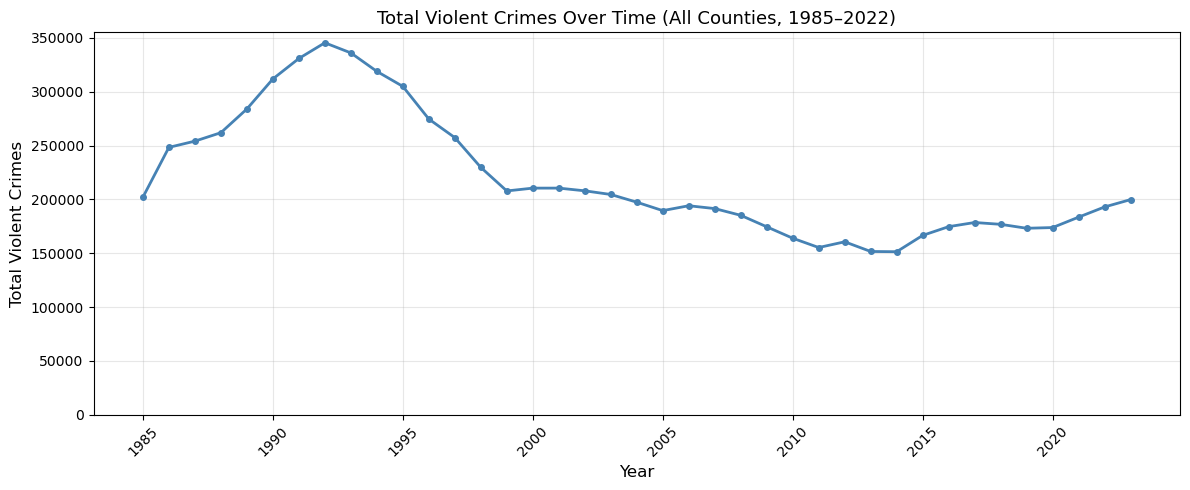

In [17]:
crime_full = pd.read_csv("../county_crime_combined_all_years.csv")                                       
crime_full = crime_full[["year", "county", "Violent Crimes"]]               
crime_full = crime_full.drop_duplicates()                                                                
crime_full["Violent Crimes"] = crime_full["Violent Crimes"].str.replace(",",                             
"").astype(float).astype("Int64")                                                                        
                                                                                                        
crime_by_year_full = crime_full.groupby("year")["Violent Crimes"].sum().reset_index()                    
                                                                                                        
fig, ax = plt.subplots(figsize=(12, 5))                                                                  
ax.plot(crime_by_year_full["year"], crime_by_year_full["Violent Crimes"],
        marker="o", color="steelblue", linewidth=2, markersize=4)                                        
ax.set_xlabel("Year", fontsize=12)                                                                       
ax.set_ylabel("Total Violent Crimes", fontsize=12)
ax.set_title("Total Violent Crimes Over Time (All Counties, 1985–2022)", fontsize=13)                    
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)                                                                                 
plt.xticks(rotation=45)
plt.tight_layout()                                                                                       
plt.show()

this also does not appear stationary

here are the augmented dickey fuller tests for both:

In [18]:
from statsmodels.tsa.stattools import adfuller
                                                                                                        
state = merged.groupby("year")[["pct_uninsured", "Violent Crimes", "population"]].sum()
state["violent_crimes_per_capita"] = state["Violent Crimes"] / state["population"]
                                                                                                        
def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")                                                    
    print(f"\n--- ADF Test: {name} ---")                                                                 
    print(f"  ADF Statistic : {result[0]:.4f}")                                                          
    print(f"  p-value       : {result[1]:.4f}")                                                          
    print(f"  Lags used     : {result[2]}")                                                              
    print(f"  Obs used      : {result[3]}")
    print("  Critical values:")                                                                          
    for level, val in result[4].items():
        print(f"    {level}: {val:.4f}")                                                                 
    print("  => Non-stationary (unit root present)" if result[1] > 0.05 else "  => Stationary (reject unit root)")                                                                                             
                                                                                                        
run_adf(state["pct_uninsured"], "Statewide Uninsured Rate")                                              
run_adf(state["violent_crimes_per_capita"], "Statewide Violent Crimes per Capita")


--- ADF Test: Statewide Uninsured Rate ---
  ADF Statistic : -1.4619
  p-value       : 0.5523
  Lags used     : 1
  Obs used      : 13
  Critical values:
    1%: -4.0689
    5%: -3.1271
    10%: -2.7017
  => Non-stationary (unit root present)

--- ADF Test: Statewide Violent Crimes per Capita ---
  ADF Statistic : 0.8819
  p-value       : 0.9928
  Lags used     : 4
  Obs used      : 10
  Critical values:
    1%: -4.3316
    5%: -3.2330
    10%: -2.7487
  => Non-stationary (unit root present)


these results also show that the series is not stationary

let's plot and try ADF on population data

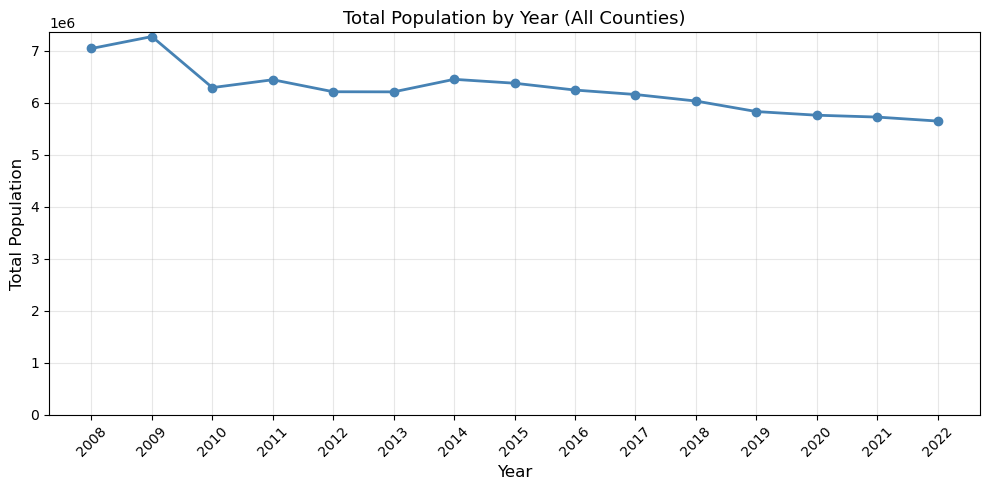

In [21]:
pop_by_year = merged.groupby("year")["population"].sum()                                                 
                                                                                                        
fig, ax = plt.subplots(figsize=(10, 5))                                                                  
ax.plot(pop_by_year.index, pop_by_year.values, marker="o", color="steelblue", linewidth=2)               
ax.set_xlabel("Year", fontsize=12)                                                                       
ax.set_ylabel("Total Population", fontsize=12)                                                           
ax.set_title("Total Population by Year (All Counties)", fontsize=13)                                     
ax.set_ylim(bottom=0)                                                                                    
ax.set_xticks(pop_by_year.index)
plt.xticks(rotation=45)                                                                                  
ax.grid(True, alpha=0.3)                                                                                 
plt.tight_layout()
plt.show()

this data also does not look stationary. it's trending down over time

ADF to confirm

In [20]:
from statsmodels.tsa.stattools import adfuller                                                         
                                                                        
pop_by_year = merged.groupby("year")["population"].sum()                                                 
                                                                                                        
result = adfuller(pop_by_year, autolag="AIC")                                                            
print("--- ADF Test: Statewide Population ---")                                                          
print(f"  ADF Statistic : {result[0]:.4f}")                                                              
print(f"  p-value       : {result[1]:.4f}")
print(f"  Lags used     : {result[2]}")                                                                  
print("  Critical values:")
for level, val in result[4].items():                                                                     
    print(f"    {level}: {val:.4f}")
print("  => Non-stationary (unit root present)" if result[1] > 0.05 else "  => Stationary (reject unit root)")
                                                                                                        
# Population is almost certainly non-stationary (trending upward), so you'll likely want to also check     
# first differences:
                                                                                                        
result_fd = adfuller(pop_by_year.diff().dropna(), autolag="AIC")
print("\n--- ADF Test: Statewide Population (First Differences) ---")                                    
print(f"  ADF Statistic : {result_fd[0]:.4f}")
print(f"  p-value       : {result_fd[1]:.4f}")                                                           
print(f"  Lags used     : {result_fd[2]}")                                                               
print("  Critical values:")
for level, val in result_fd[4].items():                                                                  
    print(f"    {level}: {val:.4f}")
print("  => Non-stationary (unit root present)" if result_fd[1] > 0.05 else "  => Stationary (reject unit root)")

--- ADF Test: Statewide Population ---
  ADF Statistic : 1.2879
  p-value       : 0.9965
  Lags used     : 4
  Critical values:
    1%: -4.3316
    5%: -3.2330
    10%: -2.7487
  => Non-stationary (unit root present)

--- ADF Test: Statewide Population (First Differences) ---
  ADF Statistic : -6.0477
  p-value       : 0.0000
  Lags used     : 5
  Critical values:
    1%: -4.6652
    5%: -3.3672
    10%: -2.8030
  => Stationary (reject unit root)


does it make sense to move forward with the first differences?

interpretation: based on only population per year, we see that it is nonstationary. when we look at the change in population per year, we see that it is stationary

let's check out the new monthly crime dataset

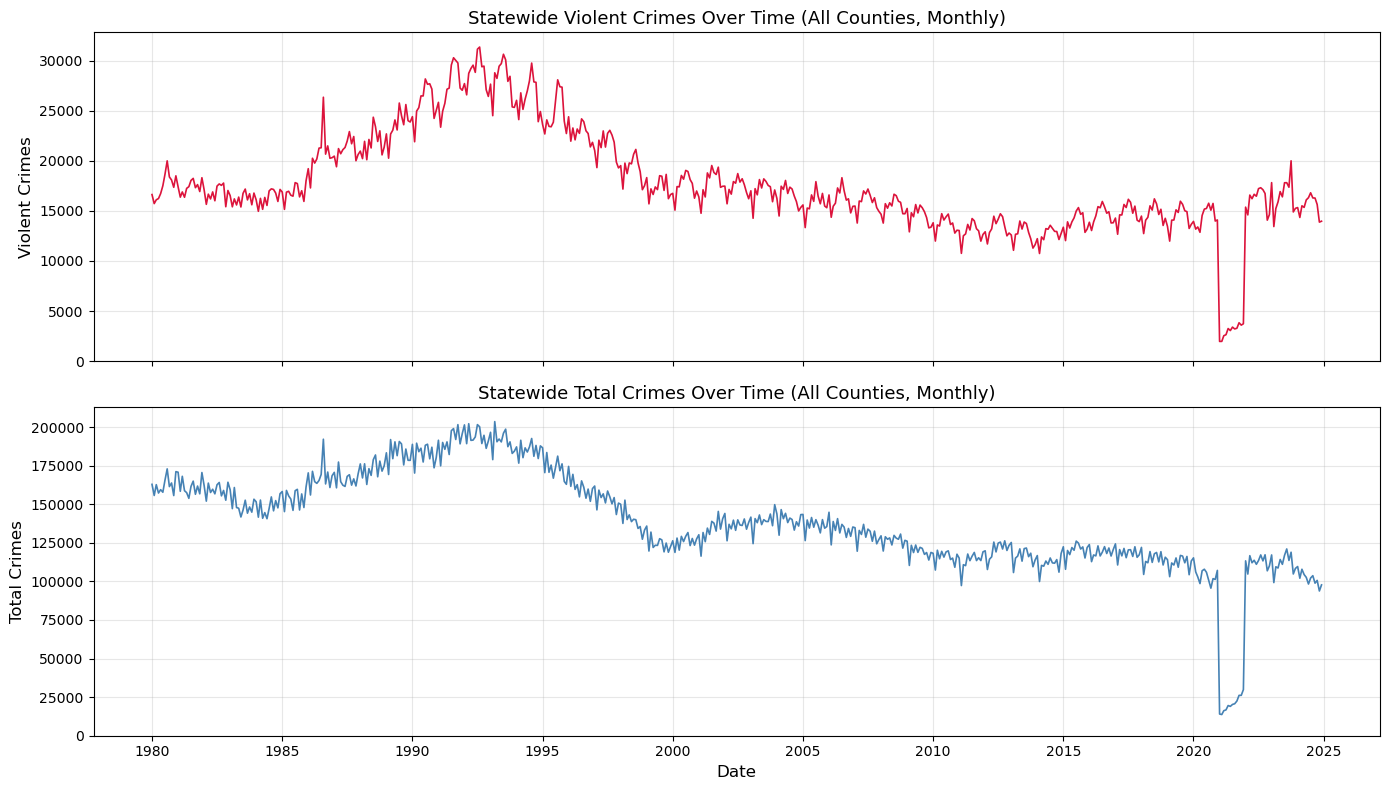

In [23]:
monthly_crime = pd.read_csv("/Users/terranchow/Desktop/other/CDCR-data/monthly_crime_by_county_1980_2024_cleaned.csv",   
parse_dates=["date"])                                                                                    
                                                                                                        
monthly_crime.head()                                                                                     
                                                                                                        
crime_by_month = monthly_crime.groupby("date")[["actual_index_violent", "actual_all_crimes"]].sum()      
                                                                                                        
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)                                       
                                                                                                        
ax1.plot(crime_by_month.index, crime_by_month["actual_index_violent"], color="crimson", linewidth=1.2)   
ax1.set_ylabel("Violent Crimes", fontsize=12)
ax1.set_title("Statewide Violent Crimes Over Time (All Counties, Monthly)", fontsize=13)                 
ax1.set_ylim(bottom=0)                                                                                   
ax1.grid(True, alpha=0.3)
                                                                                                        
ax2.plot(crime_by_month.index, crime_by_month["actual_all_crimes"], color="steelblue", linewidth=1.2)
ax2.set_ylabel("Total Crimes", fontsize=12)                                                              
ax2.set_title("Statewide Total Crimes Over Time (All Counties, Monthly)", fontsize=13)
ax2.set_xlabel("Date", fontsize=12)                                                                      
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3)                                                                                
                
plt.tight_layout()                                                                                       
plt.show()

there is a lot of monthly noise here seemingly based on season. Let's try to aggregate by year instead

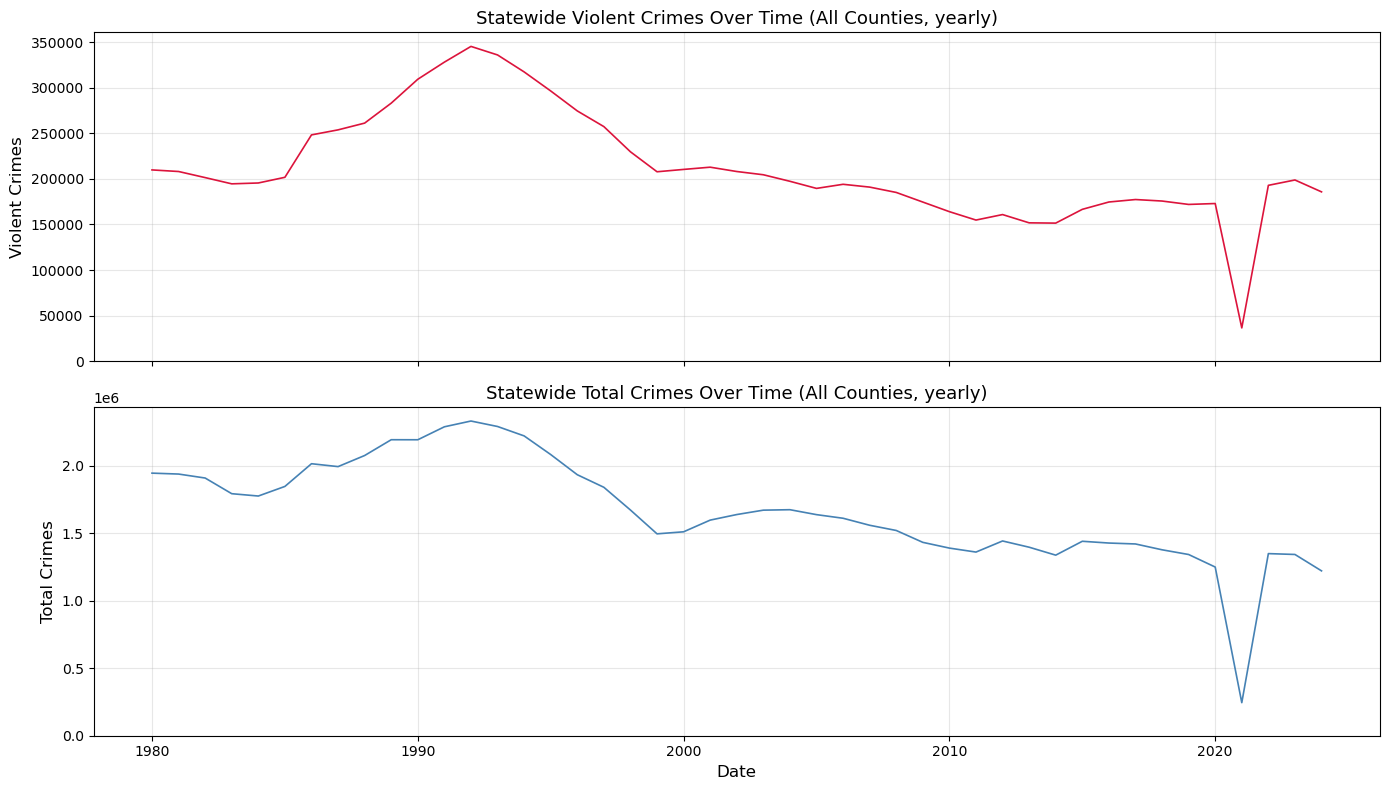

In [25]:
monthly_crime = pd.read_csv("/Users/terranchow/Desktop/other/CDCR-data/monthly_crime_by_county_1980_2024_cleaned.csv",   
parse_dates=["date"])                                                                                    
                                                                                                        
monthly_crime.head()                                                                                     
                                                                                                        
crime_by_year = monthly_crime.groupby(monthly_crime["date"].dt.year)[["actual_index_violent",            
  "actual_all_crimes"]].sum()                                                                                                        
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)                                       
                                                                                                        
ax1.plot(crime_by_year.index, crime_by_year["actual_index_violent"], color="crimson", linewidth=1.2)   
ax1.set_ylabel("Violent Crimes", fontsize=12)
ax1.set_title("Statewide Violent Crimes Over Time (All Counties, yearly)", fontsize=13)                 
ax1.set_ylim(bottom=0)                                                                                   
ax1.grid(True, alpha=0.3)
                                                                                                        
ax2.plot(crime_by_year.index, crime_by_year["actual_all_crimes"], color="steelblue", linewidth=1.2)
ax2.set_ylabel("Total Crimes", fontsize=12)                                                              
ax2.set_title("Statewide Total Crimes Over Time (All Counties, yearly)", fontsize=13)
ax2.set_xlabel("Date", fontsize=12)                                                                      
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3)                                                                                
                
plt.tight_layout()                                                                                       
plt.show()



it does not appear stationary. lets run ADF to confirm

In [28]:
from statsmodels.tsa.stattools import adfuller

crime_by_month = monthly_crime.groupby("date")[["actual_index_violent", "actual_all_crimes"]].sum()

def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n--- ADF Test: {name} ---")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Lags used     : {result[2]}")
    print("  Critical values:")
    for level, val in result[4].items():
        print(f"    {level}: {val:.4f}")
    print("  => Non-stationary (unit root present)" if result[1] > 0.05 else "  => Stationary (reject unit root)")

# Levels
run_adf(crime_by_month["actual_index_violent"], "Violent Crimes (levels)")
run_adf(crime_by_month["actual_all_crimes"], "Total Crimes (levels)")

# First differences
run_adf(crime_by_month["actual_index_violent"].diff().dropna(), "Violent Crimes (first differences)")
run_adf(crime_by_month["actual_all_crimes"].diff().dropna(), "Total Crimes (first differences)")

# Monthly crime data often has strong seasonality, which can affect ADF results. If levels come back
# non-stationary but first differences also struggle, try seasonal differencing (lag 12) as a follow-up:


# Seasonal differencing (month vs same month last year)
run_adf(crime_by_month["actual_index_violent"].diff(12).dropna(), "Violent Crimes (seasonal diff, lag=12)")                                                                                                
run_adf(crime_by_month["actual_all_crimes"].diff(12).dropna(), "Total Crimes (seasonal diff, lag=12)")


--- ADF Test: Violent Crimes (levels) ---
  ADF Statistic : -1.2481
  p-value       : 0.6526
  Lags used     : 19
  Critical values:
    1%: -3.4430
    5%: -2.8671
    10%: -2.5697
  => Non-stationary (unit root present)

--- ADF Test: Total Crimes (levels) ---
  ADF Statistic : -1.2662
  p-value       : 0.6445
  Lags used     : 14
  Critical values:
    1%: -3.4429
    5%: -2.8671
    10%: -2.5697
  => Non-stationary (unit root present)

--- ADF Test: Violent Crimes (first differences) ---
  ADF Statistic : -7.4499
  p-value       : 0.0000
  Lags used     : 18
  Critical values:
    1%: -3.4430
    5%: -2.8671
    10%: -2.5697
  => Stationary (reject unit root)

--- ADF Test: Total Crimes (first differences) ---
  ADF Statistic : -8.9348
  p-value       : 0.0000
  Lags used     : 13
  Critical values:
    1%: -3.4429
    5%: -2.8671
    10%: -2.5697
  => Stationary (reject unit root)

--- ADF Test: Violent Crimes (seasonal diff, lag=12) ---
  ADF Statistic : -4.9088
  p-value       

assuming a 12 month lag to account for years and it gave a positive result. Also, first difference shows as stationary. When I'm going to run acf/pacf to see if this is truly the best lag for violent crimes data (monthly).

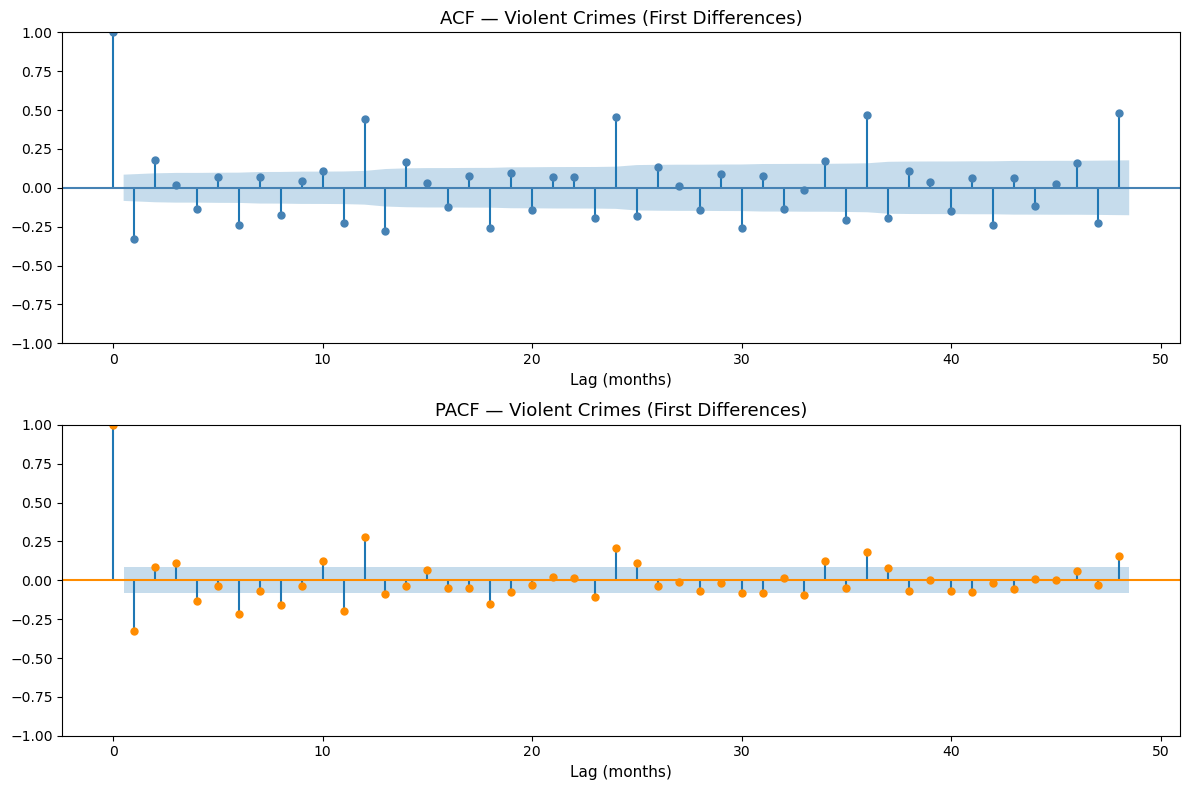

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf                                            
                                                                                                        
violent_fd = crime_by_month["actual_index_violent"].diff().dropna()                                      

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))                                                    
                                                                                                        
plot_acf(violent_fd, lags=48, ax=ax1, color="steelblue")                                                 
ax1.set_title("ACF — Violent Crimes (First Differences)", fontsize=13)
ax1.set_xlabel("Lag (months)", fontsize=11)                                                              
                
plot_pacf(violent_fd, lags=48, ax=ax2, color="darkorange")                                               
ax2.set_title("PACF — Violent Crimes (First Differences)", fontsize=13)
ax2.set_xlabel("Lag (months)", fontsize=11)                                                              
                
plt.tight_layout()
plt.show()

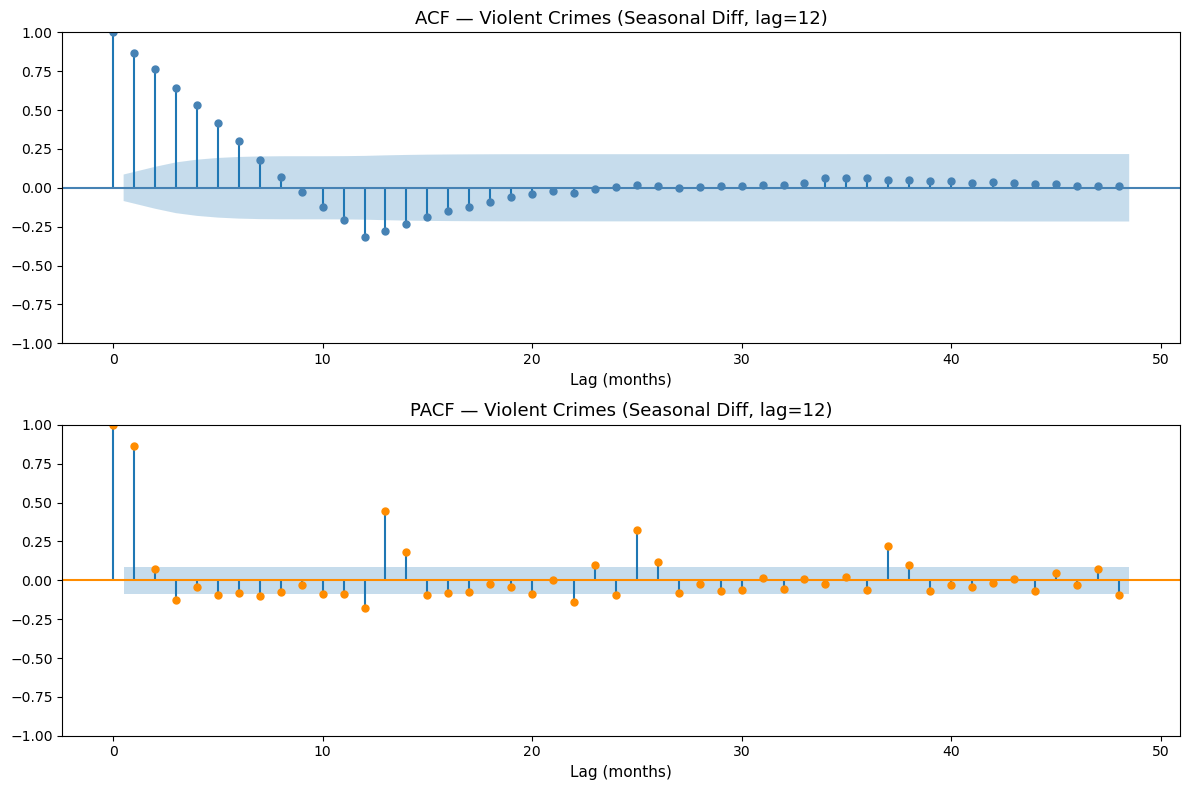

In [30]:
violent_seasonal_fd = crime_by_month["actual_index_violent"].diff(12).dropna()                         
                                                                                                        
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))                                                    
                                                                                                        
plot_acf(violent_seasonal_fd, lags=48, ax=ax1, color="steelblue")                                        
ax1.set_title("ACF — Violent Crimes (Seasonal Diff, lag=12)", fontsize=13)                             
ax1.set_xlabel("Lag (months)", fontsize=11)                                                              

plot_pacf(violent_seasonal_fd, lags=48, ax=ax2, color="darkorange")                                      
ax2.set_title("PACF — Violent Crimes (Seasonal Diff, lag=12)", fontsize=13)
ax2.set_xlabel("Lag (months)", fontsize=11)                                                              

plt.tight_layout()                                                                                       
plt.show()

the slow decay in the ACF at the low lags tells me that the trend hasn't been removed. AI tells me that i need an extra .diff() because it has "long memory". the extra .diff() changes the series from levels to changes.

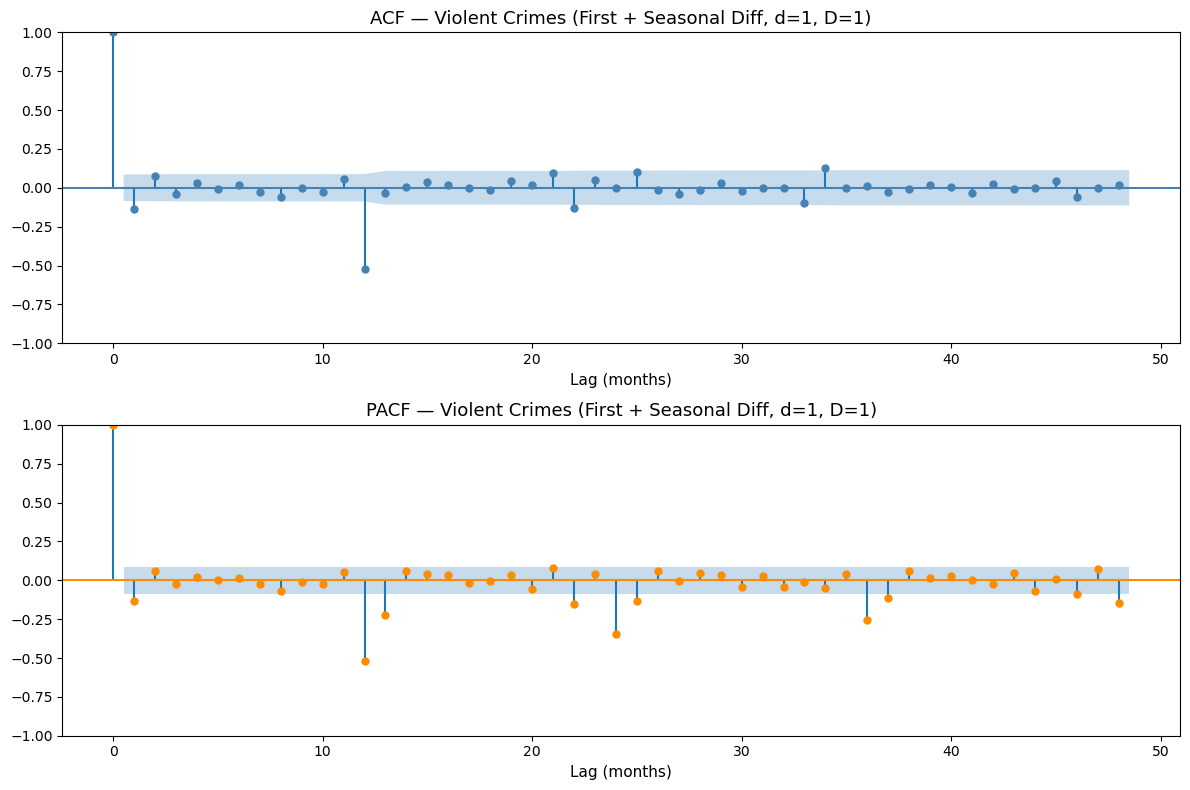

In [32]:
violent_both_fd = crime_by_month["actual_index_violent"].diff().diff(12).dropna()                        
                                                                                                        
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))                                                    
                                                                                                        
plot_acf(violent_both_fd, lags=48, ax=ax1, color="steelblue")                                            
ax1.set_title("ACF — Violent Crimes (First + Seasonal Diff, d=1, D=1)", fontsize=13)
ax1.set_xlabel("Lag (months)", fontsize=11)                                                              

plot_pacf(violent_both_fd, lags=48, ax=ax2, color="darkorange")                                          
ax2.set_title("PACF — Violent Crimes (First + Seasonal Diff, d=1, D=1)", fontsize=13)
ax2.set_xlabel("Lag (months)", fontsize=11)                                                              
                
plt.tight_layout()                                                                                       
plt.show()


the trend went away

how does all of this support our main research question?